In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

print(os.getenv("GROQ_API_KEY") is not None)

True


In [3]:

from groq import Groq

client = Groq(api_key=os.getenv("GROQ_API_KEY"))

models = client.models.list()

for model in models.data:
    print(model.id)

openai/gpt-oss-safeguard-20b
canopylabs/orpheus-arabic-saudi
whisper-large-v3
groq/compound
allam-2-7b
openai/gpt-oss-120b
whisper-large-v3-turbo
canopylabs/orpheus-v1-english
qwen/qwen3.8-27b
groq/compound-mini
meta-llama/llama-prompt-guard-2-22m
qwen/qwen3.6-27b
openai/gpt-oss-20b
meta-llama/llama-prompt-guard-2-86m


In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

In [5]:
response=llm.invoke("what is ai").content
print(response)

**Artificial Intelligence (AI)** is a branch of computer science that focuses on creating systems capable of performing tasks that normally require human intelligence. These tasks include:

| Task | Typical Human Skill | AI Approach |
|------|---------------------|-------------|
| Recognizing speech | Listening & interpreting | Speech‑to‑text models (e.g., Whisper, Whisper‑AI) |
| Understanding language | Reading & comprehension | Natural‑Language‑Processing (NLP) models (e.g., GPT‑4, BERT) |
| Seeing & interpreting images | Visual perception | Computer‑vision models (e.g., CNNs, Vision Transformers) |
| Making decisions | Reasoning & judgment | Decision‑trees, reinforcement learning, rule‑based systems |
| Learning from data | Pattern recognition | Machine‑learning algorithms (supervised, unsupervised, reinforcement) |

### Core Ideas

1. **Representation** – How information is encoded (e.g., words, images, graphs).  
2. **Learning** – Algorithms that improve performance over time by 

In [6]:
REVENUE_DATA = {
    "january": 120000, "february": 135000, "march": 142000,
    "april": 138000,   "may": 155000,      "june": 160000,
    "july": 148000,    "august": 142500,   "september": 165000,
    "october": 170000, "november": 180000, "december": 195000
}
 
ACTIVE_CUSTOMERS = 1245
 
CHURN_DATA = {
    "january": 12, "february": 15, "march": 10,
    "april": 8,    "may": 11,      "june": 9,
    "july": 14,    "august": 13,   "september": 7,
    "october": 10, "november": 12, "december": 6
}
KNOWLEDGE_SNIPPETS = [
    "A high-value customer at NexaFlow is one paying over $2,000 per month in subscription fees.",
    "NexaFlow defines churn as a customer who cancels their subscription within a given month.",
    "NexaFlow pricing tiers: Starter at $500/month, Growth at $1,500/month, Enterprise at $3,000/month.",
    "A healthy churn rate at NexaFlow is considered anything below 2% of total active customers per month.",
    "NexaFlow measures revenue as the total subscription fees collected from all active customers in a month.",
    "Customer success at NexaFlow is tracked using NPS scores collected quarterly from all paying customers."
]

In [7]:
from pydantic import BaseModel,Field

class revenue_input(BaseModel):
    month:str=Field(description="Name of the month user want income for.")
class  churn_input(BaseModel):
    month:str=Field(description="Name of the month user want churn data for.")    

In [8]:
from langchain_community.vectorstores import FAISS

/tmp/ipykernel_10220/1059762981.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [9]:
from langchain_community.embeddings import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore=FAISS.from_texts(KNOWLEDGE_SNIPPETS,embedding=embeddings)

/tmp/ipykernel_10220/1105047799.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
/home/loki/Agentic/nexaflow-agent/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1841.90it/s]


In [13]:
from langchain.tools import tool

In [14]:
retrive=vectorstore.as_retriever(search_kwargs={"k":2})

In [15]:
#Tool1
@tool(args_schema=revenue_input)
def get_revenue(month:str)->str:
    """Get the total revenue for the specific month at NexaFlow.
    Use this when user ask about revenue or income of specific month"""
    month=month.lower().strip()
    if month in REVENUE_DATA:
        return f"Revenue in {month.capitalize()}  was ₹{REVENUE_DATA[month]}."
    return f"No revenue data found in month {month}.So , Please provide a valid month."

In [16]:
#TOOL2
@tool
def get_customer_count()->str:
    """Get the total number of active customer in NexaFlow.
    Use this when user ask about active customer,user count and number of customers."""
    return f"NexaFlow curretnly has {ACTIVE_CUSTOMERS} active customers."

In [17]:
#TOOL3
@tool(args_schema=churn_input)
def get_churn_customer(month:str)->str:
    """Get the churn data for a specific month.
    Use this when user ask about how  many or count number of customers churned in the specific month"""
    month=month.lower().strip()
    if month in CHURN_DATA:
        return f"{CHURN_DATA[month]} customers churned in the month {month.capitalize()}"
    return f"No revenue data found in month {month}.So , Please provide a valid month."
    

In [18]:
#TOOL4
@tool
def knowledge_lookup(query:str)->str:
    """Lookup the NexaFlow knowledge data and answer the user query with the about policies and pricing and other company related query."""
    docs=retrive.invoke(query)
    if docs:
        result="\n".join(f"-{doc.page_content}" for doc in docs)
        return f"Here is information you asked for {query}:{result}"
    return f"There no relavant information for your {query}"

In [19]:
#TOOLKIT
tools=[get_revenue,get_customer_count,get_churn_customer,knowledge_lookup]
llm_with_tool=llm.bind_tools(tools)


In [22]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage,HumanMessage

In [23]:
#NODE

def call_llm(state:MessagesState):
    """LLM NODE-Thinck and decide which tool to use"""
    system_promt="""You are a Ai assistant for NexaFlow company.
    You have a access to tool to answer question related to company  policy,price , revenue and churn data.
    Always use the tools to get the accurate answers by using the data. 
    For questions about company policies, definitions, pricing, or customer success,
    ALWAYS use knowledge_lookup.
    Don't makeup and user general information where actual data is available"""
    messages=[SystemMessage(content=system_promt)]+state["messages"]
    response=llm_with_tool.invoke(messages)
    return {"messages":[response]}


In [24]:
from langgraph.prebuilt import ToolNode,tools_condition

In [25]:
from langgraph.graph import StateGraph,START,END

graph=StateGraph(MessagesState)

graph.add_node("llm",call_llm)
graph.add_node("tools",ToolNode(tools))

graph.add_edge(START,"llm")
graph.add_conditional_edges("llm",tools_condition)
graph.add_edge("tools","llm")

agent=graph.compile()

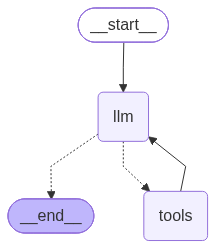

In [26]:
from IPython.display import Image,display

Image(agent.get_graph().draw_mermaid_png())

In [27]:
def run_agent(question:str)->str:
    """Run the NexaFlow agent"""
    reuslt= agent.invoke({'messages':[HumanMessage(content=question)]})
    return reuslt['messages'][-1].content

In [28]:
answer = run_agent("what is income of january")

In [29]:
answer

'The income (revenue) for January was ₹120,000.'

In [30]:
print(run_agent("How many active customers does NexaFlow have?"))

NexaFlow currently has **1,245 active customers**.


In [31]:
print(run_agent("How many customers churned in January?"))
print(run_agent("What was the churn in September?"))

In January, **12 customers churned**.
In September, **7 customers churned**.


In [32]:
print(run_agent("What is considered a high-value customer?"))

print(run_agent("What are NexaFlow's pricing plans?"))

print(run_agent("What is a healthy churn rate?"))

print(run_agent("How does NexaFlow track customer success?"))

A high‑value customer at NexaFlow is defined as one paying **over $2,000 per month** in subscription fees.
**NexaFlow Pricing Plans**

| Plan | Monthly Price | Key Features |
|------|---------------|--------------|
| **Starter** | **$500/month** | • Basic analytics dashboard<br>• Up to 5,000 monthly active users<br>• Email support |
| **Growth** | **$1,500/month** | • Advanced analytics & reporting<br>• Up to 50,000 monthly active users<br>• Priority email & chat support |
| **Enterprise** | **$3,000/month** | • Unlimited users & data<br>• Dedicated account manager<br>• 24/7 phone & chat support<br>• Custom integrations |

Feel free to let me know if you’d like more details on any specific plan or how to upgrade!
A healthy churn rate at NexaFlow is considered anything below **2% of total active customers per month**. This benchmark reflects the company’s goal of maintaining a stable and growing customer base.
NexaFlow tracks customer success primarily through **quarterly Net Promoter S

In [ ]:
def main():
    print("\t"*5+"NexaFlow Agetic AI")
    print()
    print("You can ask question about the related to the company policy ,income and active customers:")
    print(f"If you want to exit type 'exit'")
    while True:
        quesiotn=input("Your question:").lower()
        if quesiotn=="exit":
            print("Thanks, see you")
            break
        anser=run_agent(quesiotn)
        print(anser)

In [ ]:
main()

					NexaFlow Agetic AI

You can ask question about the related to the company policy ,income and active customers:
If you want to exit type 'exit'
Thanks, see you!

